# 02. 에란겔 플레이어 전략 세그먼트 분류

## 분석 흐름
```
피처 테이블 로드
  → 파생 피처 생성 (kill_rate, move_speed, heal_boost_use)
  → Winsorizing (1~99 퍼센타일 클리핑, 데이터 손실 없음)
  → Robust Z-Score 정규화 (이상치 강건)
  → 페르소나 점수 계산 (4개 타입 정의 기반)
  → Margin 임계값으로 uncertain 분리
  → UMAP 시각화 (분류 후 시각적 확인용)
  → 모델 저장
```

## 4개 전략 페르소나
| 페르소나 | 핵심 특징 |
|----------|-----------|
| 🏃 중앙 점령형 | 비행기 경로 중앙 낙하, 핫드랍, 선점 로테이션, 높은 킬 |
| 🌿 외곽 운영형 | 외곽 낙하, 저밀도 지역, 안전구역 근접, 힐템 활용 |
| ⚔️ 중앙 교전형 | 극단적 핫드랍, 매우 높은 킬+딜, 빠른 이동 |
| 🦅 게릴라 운영형 | 차량 비선호, 존타기 수용, 후행 로테이션, 힐 중심 |

## HDBSCAN을 사용하지 않는 이유
HDBSCAN은 "데이터 구조에서 자연스러운 클러스터를 탐색"하는 도구입니다.  
이 데이터에서는 반복 실험 결과 항상 2~3개 덩어리만 생성되어 의미 있는 분류가 어려웠습니다.  
우리의 목적은 **이미 정의된 4개 전략 타입으로 분류**하는 것이므로,  
Robust Z-Score 기반 스코어 방식이 더 안정적이고 해석 가능합니다.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

import umap
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 이모지 폰트 지정
mpl.rcParams['font.family'] = ['Malgun Gothic', 'Segoe UI Emoji']

# ── 공통 설정 로드 (config.py) ──
%run config.py

print('설정 완료')

   config.py 로드 완료
   BASE_DIR  : C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/
   DATE      : 20260212 ~ 20260227
   MAPS      : ['Erangel', 'Miramar', 'Taego', 'Rondo']
설정 완료


In [2]:
# STEP 1: 피처 테이블 로드 + 스키마 검증
# [피드백 반영] config.py의 TRUTH_TABLES에서 경로를 읽어
# 단일 진실 테이블(erangel_features.parquet)만 사용
# 컬럼 누락 시 즉시 실패 (silent NaN 대체 방지)

df = pd.read_parquet(TRUTH_TABLES['erangel_features'])
print(f'로드 완료: {df.shape[0]:,}행 × {df.shape[1]}열')

# 스키마 검증: REQUIRED_COLS 기준으로 누락 컬럼 즉시 실패
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise RuntimeError(
        f" 스키마 불일치 — 누락 컬럼 {len(missing)}개: {missing}\n"
        f"  → 01_data_pipeline 재실행 또는 config.py REQUIRED_COLS 확인"
    )
print(f" 스키마 검증 통과")
display(df.head(3))


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/qkrtl/10th/00_Project/04_final/02_parquet_file/04_temp_parquet_files/analysis_output\\erangel_features.parquet'

In [ ]:
# STEP 2: 파생 피처 생성 + 기초 전처리
# 이번 버전은 HDBSCAN 방식을 폐기하고
# Robust Z-Score 기반 스코어 세그먼트 방식으로 전면 전환합니다.
#
# [이유]
#  HDBSCAN은 "데이터가 몇 개 덩어리인지 탐색"하는 도구
#  우리 목적은 이미 정의된 4개 전략 타입에 각 플레이어를 분류하는 것
#  → 스코어 기반 분류가 목적에 더 정확히 부합
#
# [Robust Z-Score란]
# 중앙값(median) + MAD(Median Absolute Deviation) 기반 표준화
# 평균/표준편차보다 이상치에 훨씬 강건 → 극단 플레이어도 안정적으로 처리

# 생존 시간 최소 2분 이상 필터
df_clean = df[df['survival_time'] >= 120].copy()
print(f'생존 2분 이상 필터: {len(df_clean):,}행 ({len(df_clean)/len(df):.1%} 유지)')

# 파생 피처
df_clean['kill_rate']      = df_clean['kills'].fillna(0) / (df_clean['survival_time'] / 60 + 1e-9)
df_clean['move_speed']     = df_clean['walkDistance'].fillna(0) / (df_clean['survival_time'] + 1e-9)
df_clean['heal_boost_use'] = df_clean['heals'].fillna(0) + df_clean['boosts'].fillna(0)

# 결측치 중앙값 대체
fill_cols = [
    'drop_distance_from_path', 'early_enemy_density', 'rotation_timing_score',
    'vehicle_use_ratio', 'bluezone_exposure_ratio', 'safezone_proximity_mean',
    'safezone_edge_ratio', 'altitude_variance',
    'kill_rate', 'move_speed', 'heal_boost_use',
]
for col in fill_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('결측치 보완 완료')
print()
print('피처 기초 통계:')
display(df_clean[fill_cols].describe().round(3))

생존 2분 이상 필터: 213,526행 (91.2% 유지)
결측치 보완 완료

피처 기초 통계:


,drop_distance_from_path,early_enemy_density,rotation_timing_score,vehicle_use_ratio,bluezone_exposure_ratio,safezone_proximity_mean,safezone_edge_ratio,altitude_variance,kill_rate,move_speed,heal_boost_use
count,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000
mean,788.457,4.548,0.548,0.150,0.059,1455.084,0.006,3285.003,0.072,2.009,6.042
std,476.594,5.570,0.075,0.143,0.108,730.914,0.333,5146.268,0.128,0.887,6.185
min,0.016,0.000,0.064,0.000,0.000,53.678,0.000,0.000,0.000,0.000,0.000
25%,382.531,0.000,0.503,0.000,0.000,885.208,0.004,517.188,0.000,1.639,1.000
50%,770.503,3.000,0.544,0.133,0.000,1290.298,0.005,1267.759,0.000,2.086,4.000
75%,1163.192,7.000,0.593,0.248,0.075,1952.278,0.006,2686.275,0.104,2.532,9.000
max,3721.313,50.000,0.974,1.000,1.000,5443.931,123.962,73967.948,4.000,33.892,104.000


In [ ]:
# STEP 3: Winsorizing (이상치 클리핑)
# 전략 분류에서 극단값은 의미있는 신호입니다.
# (상위 1% 킬률 = 프로급 공격형, 상위 1% 낙하거리 = 극단 외곽형)
# → IQR 제거 대신 1~99 퍼센타일 클리핑으로 데이터 유지 + 분포 안정화

winsor_cols = [
    'drop_distance_from_path', 'early_enemy_density',
    'safezone_proximity_mean', 'altitude_variance',
    'kill_rate', 'move_speed', 'heal_boost_use',
]
for col in winsor_cols:
    lo = df_clean[col].quantile(0.01)
    hi = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lo, hi)

print(f'Winsorizing 완료 — 데이터 유지: {len(df_clean):,}행 (손실 없음)')
print()

# 간단한 분포 확인
print('Winsorizing 후 주요 피처 범위:')
for col in ['drop_distance_from_path', 'early_enemy_density', 'kill_rate']:
    print(f'  {col:<35} min={df_clean[col].min():.3f}  max={df_clean[col].max():.3f}')

Winsorizing 완료 — 데이터 유지: 213,526행 (손실 없음)

Winsorizing 후 주요 피처 범위:
  drop_distance_from_path             min=14.010  max=1792.934
  early_enemy_density                 min=0.000  max=24.000
  kill_rate                           min=0.000  max=0.563


In [ ]:
# ※ 이 구조는 K-means/HDBSCAN 같은 '발견된 군집(Clustering)'이 아닌
#    'Robust Z-Score 점수 기반 규칙 배정(Persona Scoring)'입니다.
#    argmax(점수)로 세그먼트가 결정되며, margin 미달은 uncertain 처리.
# STEP 4: Robust Z-Score 계산
#
# robust_z(x) = (x - median(x)) / (1.4826 * MAD(x))
# - 1.4826: 정규분포 가정 하의 보정 상수 (MAD → 표준편차 스케일 변환)
# - MAD = 0이면 1.0으로 대체 (상수 피처 보호)
#
# 각 피처를 동일 스케일로 변환해야 점수 계산 시 특정 피처가 지배하지 않음

def robust_z(s: pd.Series) -> pd.Series:
    med = s.median()
    mad = (s - med).abs().median()
    mad = mad if mad != 0 else 1.0
    return (s - med) / (1.4826 * mad)

z = pd.DataFrame(index=df_clean.index)
z['drop']    = robust_z(df_clean['drop_distance_from_path'])
z['density'] = robust_z(df_clean['early_enemy_density'])
z['rot']     = robust_z(df_clean['rotation_timing_score'])
z['vehicle'] = robust_z(df_clean['vehicle_use_ratio'])
z['blue']    = robust_z(df_clean['bluezone_exposure_ratio'])
z['safe']    = -robust_z(df_clean['safezone_proximity_mean'])   # 음수: 가까울수록 +
z['edge']    = robust_z(df_clean['safezone_edge_ratio'])
z['kill']    = robust_z(df_clean['kill_rate'])
z['speed']   = robust_z(df_clean['move_speed'])
z['heal']    = robust_z(df_clean['heal_boost_use'])

print('Robust Z-Score 계산 완료')
print(f'  shape: {z.shape}')
print()
print('Z-Score 분포 확인 (중앙값은 0에 가까워야 함):')
display(z.describe().round(3))

Robust Z-Score 계산 완료
  shape: (213526, 10)

Z-Score 분포 확인 (중앙값은 0에 가까워야 함):


,drop,density,rot,vehicle,blue,safe,edge,kill,speed,heal
count,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000,213526.000
mean,0.029,0.336,0.065,0.088,0.040,-0.226,0.942,0.047,-0.123,0.336
std,0.819,1.199,1.142,0.727,0.073,1.003,183.766,0.074,1.313,1.008
min,-1.307,-0.674,-7.271,-0.674,0.000,-2.761,-2.574,0.000,-3.148,-0.674
25%,-0.670,-0.674,-0.630,-0.674,0.000,-0.921,-0.677,0.000,-0.675,-0.506
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.679,0.899,0.742,0.584,0.051,0.564,0.671,0.070,0.674,0.843
max,1.767,4.721,6.512,4.400,0.674,1.290,68465.604,0.380,2.856,3.541


In [ ]:
# ※ 이 구조는 '발견된 군집(클러스터링)'이 아닌
#    'Robust Z-Score 점수 기반 규칙 배정(페르소나 스코어링)'입니다.
#    argmax(점수)로 세그먼트가 결정 — margin 미달은 uncertain 처리.
# STEP 5: 페르소나 점수 계산 + 세그먼트 라벨링
#
# 4개 페르소나 정의:
# 중앙 점령형         : 낙하↓ + 적밀도↑ + 선점로테이션 + 킬↑ 
# 외곽 운영형         : 낙하↑ + 적밀도↓ + 외곽포지션 + 안전구역근접 + 힐
# 중앙 교전형         : 적밀도↑↑ + 킬↑↑ + 이동속도↑ 
# 게릴라 운영형       : 차량↓ + 존타기↑ + 후행로테이션 + 힐↑ 
#
# margin(1등-2등 점수 차) < threshold → 'uncertain' (어느 타입에도 확실하지 않음)

PERSONA_LABELS = {
    'C0_center':   '🏃 중앙 점령형',
    'C1_edge':     '🌿 외곽 운영형',
    'C2_aggro':    '⚔️ 중앙 교전형',
    'C3_guerilla': '🦅 게릴라 운영형',
    'uncertain':   '❓ 혼합형',
}

# 점수 계산
# rotation_timing_score: 낮을수록 선점(early) → -z['rot']
scores = pd.DataFrame({
    'C0_center':   z['density'] - z['rot'] - z['drop'] + z['kill'],
    'C1_edge':     z['drop'] - z['density'] + z['edge'] - z['safe'] + z['heal'],
    'C2_aggro':    1.5*z['density'] + 1.5*z['kill'] + z['speed'],
    'C3_guerilla': -z['vehicle'] + z['blue'] + z['rot'] + 0.5*z['heal'],
}, index=df_clean.index)

# argmax로 최고 점수 페르소나 결정
best_persona  = scores.idxmax(axis=1)
best_score    = scores.max(axis=1)
second_score  = scores.apply(lambda r: r.nlargest(2).iloc[-1], axis=1)
margin        = best_score - second_score

# 임계값 설정 (margin < 0.5 → uncertain)
MARGIN_THRESHOLD = 0.5
df_clean['segment']    = best_persona
df_clean['margin']     = margin
df_clean['persona']    = df_clean['segment'].map(PERSONA_LABELS)
df_clean.loc[margin < MARGIN_THRESHOLD, 'segment'] = 'uncertain'
df_clean.loc[margin < MARGIN_THRESHOLD, 'persona'] = PERSONA_LABELS['uncertain']

# 점수 컬럼도 저장
for col in scores.columns:
    df_clean[f'score_{col}'] = scores[col]

# 결과 요약
print(f'세그먼트 분류 완료 (margin threshold={MARGIN_THRESHOLD})')
print()
seg_counts = df_clean['persona'].value_counts()
for persona, cnt in seg_counts.items():
    print(f'  {persona}: {cnt:,}명 ({cnt/len(df_clean):.1%})')
print()
print(f'※ 혼합형 비율이 너무 높으면 MARGIN_THRESHOLD를 낮추세요 (현재: {MARGIN_THRESHOLD})')
print(f'  혼합형 비율: {(df_clean["segment"]=="uncertain").mean():.1%}')

세그먼트 분류 완료 (margin threshold=0.5)

  🌿 외곽 운영형: 70,090명 (32.8%)
  ❓ 혼합형: 48,540명 (22.7%)
  🏃 중앙 점령형: 34,863명 (16.3%)
  ⚔️ 중앙 교전형: 32,820명 (15.4%)
  🦅 게릴라 운영형: 27,213명 (12.7%)

※ 혼합형 비율이 너무 높으면 MARGIN_THRESHOLD를 낮추세요 (현재: 0.5)
  혼합형 비율: 22.7%


In [ ]:
# STEP 6: 세그먼트별 피처 프로파일
#
# uncertain 제외 4개 세그먼트의 중앙값 비교
# → 각 페르소나가 실제로 정의와 맞게 분류됐는지 검증

FEATURE_COLS_DISPLAY = [
    'drop_distance_from_path', 'early_enemy_density', 'rotation_timing_score',
    'vehicle_use_ratio', 'bluezone_exposure_ratio', 'safezone_proximity_mean',
    'safezone_edge_ratio', 'altitude_variance', 'kill_rate', 'move_speed', 'heal_boost_use',
]

profile = (
    df_clean[df_clean['segment'] != 'uncertain']
    .groupby('persona')[FEATURE_COLS_DISPLAY]
    .median()
    .round(3)
)

print('페르소나별 피처 중앙값:')
display(profile)
print()

# 피처별로 어떤 페르소나가 최고값/최저값인지 확인
print('피처별 최고/최저 페르소나:')
for col in FEATURE_COLS_DISPLAY:
    hi = profile[col].idxmax()
    lo = profile[col].idxmin()
    print(f'  {col:<35} 최고: {hi}  최저: {lo}')

페르소나별 피처 중앙값:


,drop_distance_from_path,early_enemy_density,rotation_timing_score,vehicle_use_ratio,bluezone_exposure_ratio,safezone_proximity_mean,safezone_edge_ratio,altitude_variance,kill_rate,move_speed,heal_boost_use
persona,,,,,,,,,,,
⚔️ 중앙 교전형,703.725,10.0,0.544,0.000,0.000,1308.039,0.004,458.795,0.046,2.759,2.0
🌿 외곽 운영형,1160.436,0.0,0.543,0.230,0.068,1670.730,0.006,1748.394,0.000,2.023,8.0
🏃 중앙 점령형,357.837,5.0,0.493,0.000,0.000,1057.106,0.004,888.933,0.000,1.652,1.0
🦅 게릴라 운영형,651.429,0.0,0.651,0.115,0.000,896.623,0.004,1495.370,0.000,1.946,6.0



피처별 최고/최저 페르소나:
  drop_distance_from_path             최고: 🌿 외곽 운영형  최저: 🏃 중앙 점령형
  early_enemy_density                 최고: ⚔️ 중앙 교전형  최저: 🌿 외곽 운영형
  rotation_timing_score               최고: 🦅 게릴라 운영형  최저: 🏃 중앙 점령형
  vehicle_use_ratio                   최고: 🌿 외곽 운영형  최저: ⚔️ 중앙 교전형
  bluezone_exposure_ratio             최고: 🌿 외곽 운영형  최저: ⚔️ 중앙 교전형
  safezone_proximity_mean             최고: 🌿 외곽 운영형  최저: 🦅 게릴라 운영형
  safezone_edge_ratio                 최고: 🌿 외곽 운영형  최저: ⚔️ 중앙 교전형
  altitude_variance                   최고: 🌿 외곽 운영형  최저: ⚔️ 중앙 교전형
  kill_rate                           최고: ⚔️ 중앙 교전형  최저: 🌿 외곽 운영형
  move_speed                          최고: ⚔️ 중앙 교전형  최저: 🏃 중앙 점령형
  heal_boost_use                      최고: 🌿 외곽 운영형  최저: 🏃 중앙 점령형


In [ ]:
# STEP 7: 승률 분석

result_cols_check = ['win_flag','top3_flag','kills','damageDealt','winPlace']
avail = [c for c in result_cols_check if c in df_clean.columns]

seg_results = (
    df_clean[df_clean['segment'] != 'uncertain']
    .groupby('persona')
    .agg(
        n_players   = ('win_flag', 'count'),
        win_rate    = ('win_flag', 'mean'),
        top3_rate  = ('top3_flag', 'mean'),
        avg_kills   = ('kills', 'mean'),
        avg_damage  = ('damageDealt', 'mean'),
        avg_winplace= ('winPlace', 'mean'),
    )
    .round(3)
    .reset_index()
)

print('페르소나별 게임 결과:')
display(seg_results.sort_values('win_rate', ascending=False))

페르소나별 게임 결과:


,persona,n_players,win_rate,top3_rate,avg_kills,avg_damage,avg_winplace
3,🦅 게릴라 운영형,23986,0.140,0.854,1.304,268.690,5.721
1,🌿 외곽 운영형,68077,0.069,0.738,1.082,190.410,7.561
0,⚔️ 중앙 교전형,32815,0.040,0.338,1.200,187.460,12.524
2,🏃 중앙 점령형,25473,0.038,0.481,1.009,171.668,10.393


UMAP 시각화용 차원 축소 중... (수분 소요 가능)
UMAP 완료: (213526, 2)


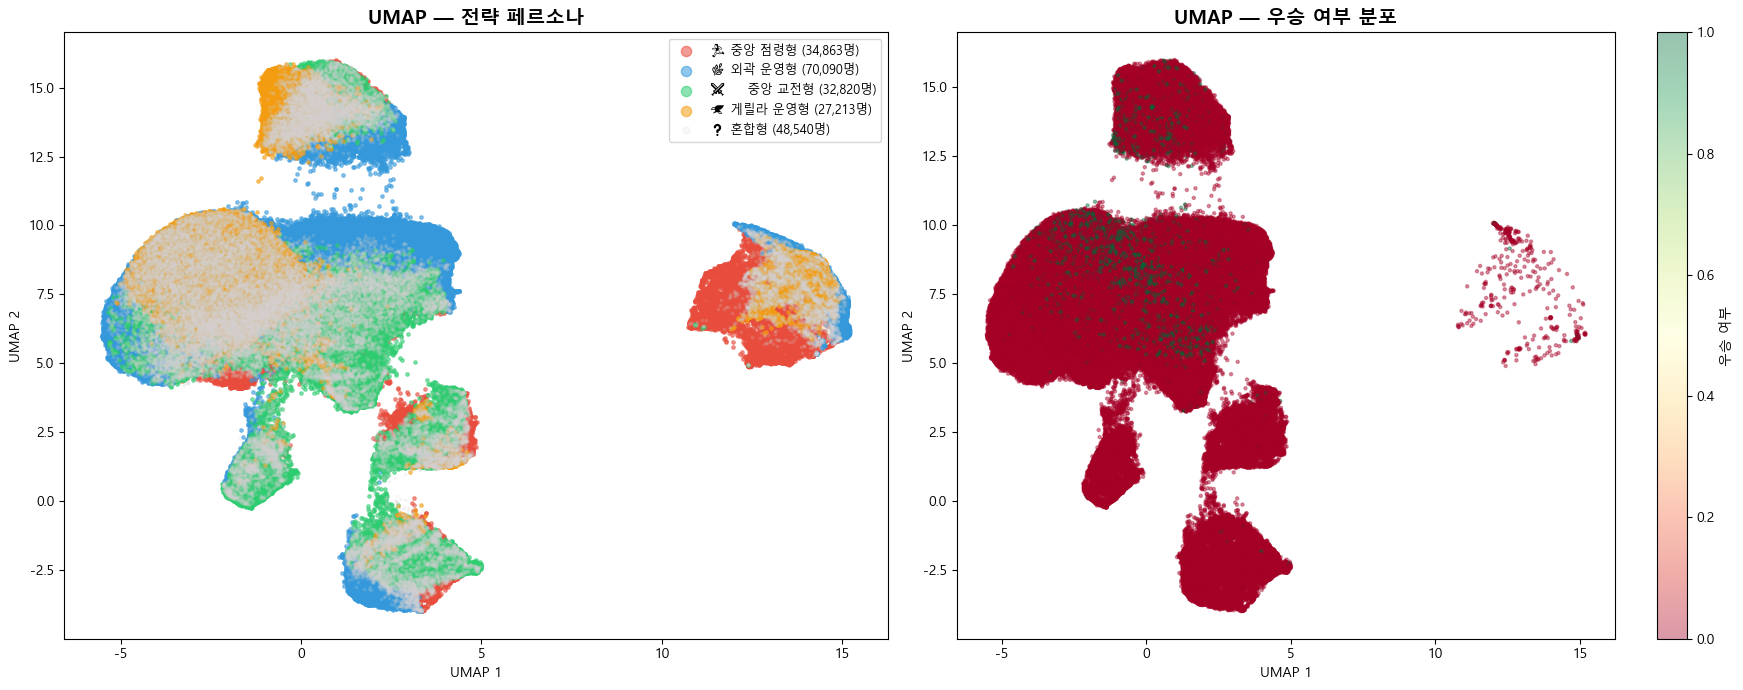

저장 완료: umap_segments.png


In [ ]:
# STEP 8: UMAP 시각화 (세그먼트 색상)
#
# UMAP은 이제 분류에 사용하지 않고 시각화 전용으로만 사용
# → 세그먼트가 UMAP 공간에서 어떻게 분포하는지 확인

print('UMAP 시각화용 차원 축소 중... (수분 소요 가능)')

# 시각화용 피처 행렬 (StandardScaler)
feat_matrix = df_clean[FEATURE_COLS_DISPLAY].values
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_vis   = scaler.fit_transform(imputer.fit_transform(feat_matrix))

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
    verbose=False,
)
embedding = reducer.fit_transform(X_vis)
df_clean['umap_x'] = embedding[:, 0]
df_clean['umap_y'] = embedding[:, 1]

print(f'UMAP 완료: {embedding.shape}')

# ── 시각화 ──
COLORS = {
    '🏃 중앙 점령형':       '#E74C3C',
    '🌿 외곽 운영형':       '#3498DB',
    '⚔️ 중앙 교전형':       '#2ECC71',
    '🦅 게릴라 운영형':     '#F39C12',
    '❓ 혼합형':            'lightgray',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 왼쪽: 페르소나 색상
ax = axes[0]
for persona, color in COLORS.items():
    mask = df_clean['persona'] == persona
    if not mask.any():
        continue
    alpha = 0.15 if persona == '❓ 혼합형' else 0.55
    size  = 3     if persona == '❓ 혼합형' else 6
    ax.scatter(
        df_clean.loc[mask, 'umap_x'],
        df_clean.loc[mask, 'umap_y'],
        c=color, alpha=alpha, s=size, label=f'{persona} ({mask.sum():,}명)',
    )
ax.set_title('UMAP — 전략 페르소나', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', markerscale=3, fontsize=9)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# 오른쪽: 승률 히트맵
ax2 = axes[1]
non_unc = df_clean[df_clean['segment'] != 'uncertain']
sc = ax2.scatter(
    non_unc['umap_x'], non_unc['umap_y'],
    c=non_unc['win_flag'], cmap='RdYlGn',
    alpha=0.4, s=5, vmin=0, vmax=1,
)
plt.colorbar(sc, ax=ax2, label='우승 여부')
ax2.set_title('UMAP — 우승 여부 분포', fontsize=14, fontweight='bold')
ax2.set_xlabel('UMAP 1'); ax2.set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_segments.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: umap_segments.png')

그릴 페르소나 (4개): ['🏃 중앙 점령형', '🌿 외곽 운영형', '⚔️ 중앙 교전형', '🦅 게릴라 운영형']


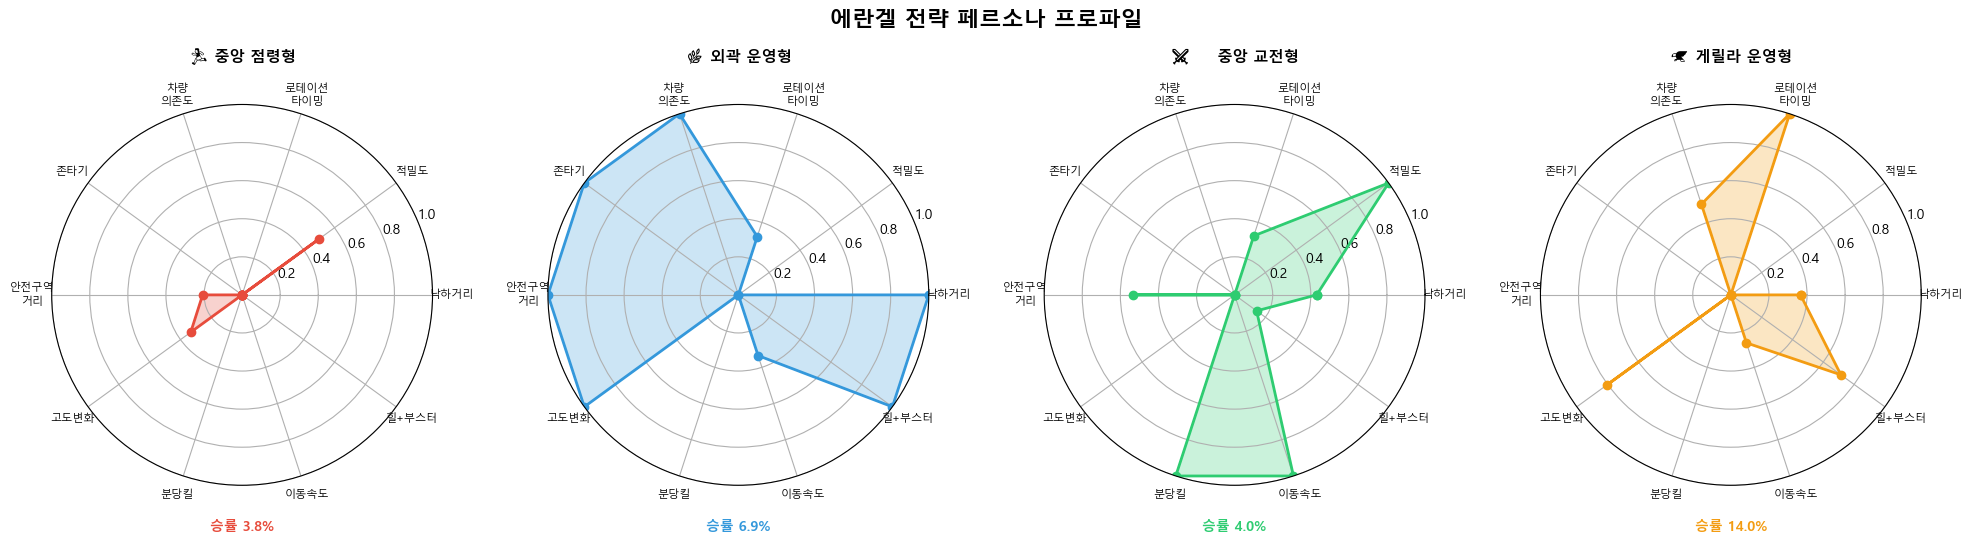

저장 완료: segment_radar.png

정규화된 피처 중앙값 (0~1, 0=4개 중 최저 1=4개 중 최고):
           drop_distance_from_path  early_enemy_density  rotation_timing_score  vehicle_use_ratio  bluezone_exposure_ratio  safezone_proximity_mean  altitude_variance  kill_rate  move_speed  heal_boost_use
persona                                                                                                                                                                                                      
⚔️ 중앙 교전형                    0.431                  1.0                  0.326                0.0                      0.0                    0.531              0.000        1.0       1.000           0.143
🌿 외곽 운영형                     1.000                  0.0                  0.321                1.0                      1.0                    1.000              1.000        0.0       0.335           1.000
🏃 중앙 점령형                     0.000                  0.5                  0.000                0.0             

In [ ]:
# STEP 9: 레이더 차트 — 페르소나 프로파일
#
# [버그 수정]
# 기존 코드: name_map으로 이모지를 제거한 뒤 PLOT_ORDER와 매칭 시도
#   → profile_norm.index는 이모지 포함 / PLOT_ORDER는 이모지 없음
#   → valid_order = [] → 레이더 차트가 빈 상태로 저장됨
# 수정: name_map/rename 완전 제거, PERSONA_LABELS 기반으로 순서 통일

RADAR_COLS = [
    'drop_distance_from_path', 'early_enemy_density', 'rotation_timing_score',
    'vehicle_use_ratio', 'bluezone_exposure_ratio', 'safezone_proximity_mean',
    'altitude_variance', 'kill_rate', 'move_speed', 'heal_boost_use',
]
RADAR_LABELS = [
    '낙하거리', '적밀도', '로테이션\n타이밍', '차량\n의존도', '존타기',
    '안전구역\n거리', '고도변화', '분당킬', '이동속도', '힐+부스터',
]

profile_radar = (
    df_clean[df_clean['segment'] != 'uncertain']
    .groupby('persona')[RADAR_COLS]
    .median()
)

# 피처별 min-max 정규화
# 0 = 4개 페르소나 중 해당 피처 최저 (버그 아님, 상대적 최저를 의미)
# 1 = 4개 페르소나 중 해당 피처 최고
profile_norm = (profile_radar - profile_radar.min()) / (
    profile_radar.max() - profile_radar.min() + 1e-9
)

# ── PERSONA_LABELS 정의 순서대로 정렬 (이모지 포함 그대로 사용) ──
PLOT_ORDER = [v for k, v in PERSONA_LABELS.items() if k != 'uncertain']
valid_order = [p for p in PLOT_ORDER if p in profile_norm.index]
print(f"그릴 페르소나 ({len(valid_order)}개): {valid_order}")

PLOT_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

N      = len(RADAR_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, axes = plt.subplots(
    1, len(valid_order),
    figsize=(5 * len(valid_order), 5),
    subplot_kw={'polar': True},
)
if len(valid_order) == 1:
    axes = [axes]

for idx, persona in enumerate(valid_order):
    ax    = axes[idx]
    color = PLOT_COLORS[idx % len(PLOT_COLORS)]
    vals  = profile_norm.loc[persona, RADAR_COLS].tolist() + [profile_norm.loc[persona, RADAR_COLS[0]]]

    ax.plot(angles, vals, 'o-', linewidth=2, color=color)
    ax.fill(angles, vals, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(persona, fontsize=11, fontweight='bold', pad=15)

    wr_row = seg_results[seg_results['persona'] == persona]
    if not wr_row.empty:
        ax.text(0.5, -0.12,
                f'승률 {wr_row["win_rate"].values[0]:.1%}',
                transform=ax.transAxes, ha='center',
                fontsize=10, color=color, fontweight='bold')

plt.suptitle('에란겔 전략 페르소나 프로파일', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'segment_radar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: segment_radar.png')
print()
print("정규화된 피처 중앙값 (0~1, 0=4개 중 최저 1=4개 중 최고):")
print(profile_norm.round(3).to_string())

 사용 피처 (10개): ['drop_distance_from_path', 'early_enemy_density', 'rotation_timing_score', 'vehicle_use_ratio', 'bluezone_exposure_ratio', 'safezone_proximity_mean', 'altitude_variance', 'kill_rate', 'move_speed', 'heal_boost_use']
그릴 페르소나 (4개): ['🏃 중앙 점령형', '🌿 외곽 운영형', '⚔️ 중앙 교전형', '🦅 게릴라 운영형']


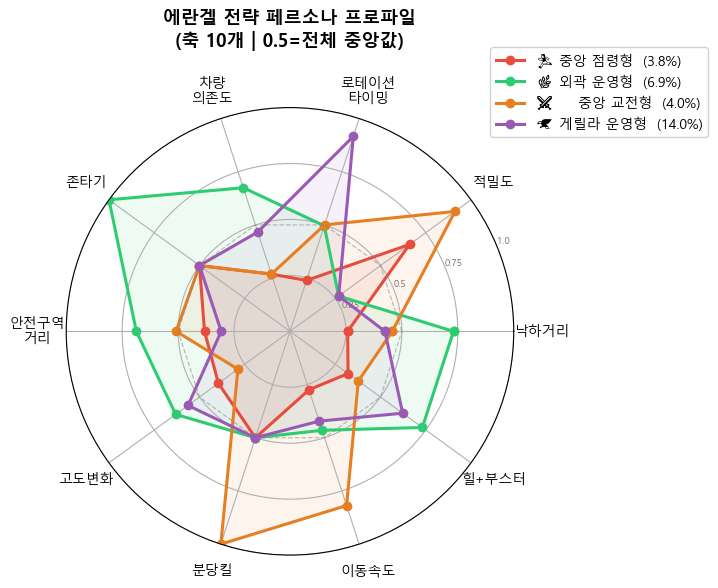

저장 완료: segment_radar.png

정규화값 (0~1, 0.5=전체 중앙):
           drop_distance_from_path  early_enemy_density  rotation_timing_score  vehicle_use_ratio  bluezone_exposure_ratio  safezone_proximity_mean  altitude_variance  kill_rate  move_speed  heal_boost_use
persona                                                                                                                                                                                                      
⚔️ 중앙 교전형                    0.457                0.912                  0.500              0.269                      0.5                    0.509              0.288        1.0       0.819           0.378
🌿 외곽 운영형                     0.731                0.269                  0.496              0.675                      1.0                    0.687              0.632        0.5       0.465           0.731
🏃 중앙 점령형                     0.258                0.661                  0.239              0.269                      0.5     

In [ ]:
# STEP 9: 레이더 차트 — 페르소나 프로파일
# [개선]
# 1. 저분산(변별력 없는) 축 제거 — range ≤ eps인 피처 제외
# 2. 4개 페르소나를 개별 subplot 대신 하나의 레이더에 겹쳐서 비교
#    → 페르소나 간 차이가 한눈에 보임

RADAR_COLS = [
    'drop_distance_from_path', 'early_enemy_density', 'rotation_timing_score',
    'vehicle_use_ratio', 'bluezone_exposure_ratio', 'safezone_proximity_mean',
    'altitude_variance', 'kill_rate', 'move_speed', 'heal_boost_use',
]
RADAR_LABEL_MAP = {
    'drop_distance_from_path': '낙하거리',
    'early_enemy_density':     '적밀도',
    'rotation_timing_score':   '로테이션\n타이밍',
    'vehicle_use_ratio':       '차량\n의존도',
    'bluezone_exposure_ratio': '존타기',
    'safezone_proximity_mean': '안전구역\n거리',
    'altitude_variance':       '고도변화',
    'kill_rate':               '분당킬',
    'move_speed':              '이동속도',
    'heal_boost_use':          '힐+부스터',
}
PLOT_COLORS = ['#E74C3C', '#2ECC71', '#E67E22', '#9B59B6']

# 페르소나별 중앙값
profile_radar = (
    df_clean[df_clean['segment'] != 'uncertain']
    .groupby('persona')[RADAR_COLS]
    .median()
)

# ── Step 1: 저분산 축 제거 ──
eps       = 1e-6
col_range = profile_radar.max() - profile_radar.min()
keep_cols = [c for c in RADAR_COLS if col_range.get(c, 0) > eps]
drop_cols = [c for c in RADAR_COLS if col_range.get(c, 0) <= eps]
if drop_cols:
    print(f" 변별력 없어 제외 ({len(drop_cols)}개): {drop_cols}")
print(f" 사용 피처 ({len(keep_cols)}개): {keep_cols}")

# ── Step 2: 정규화 (페르소나 간 상대 위치) ──
# 전체 플레이어 분포 기준 Robust Z → Sigmoid
all_vals  = df_clean[keep_cols]
all_med   = all_vals.median()
all_mad   = (all_vals - all_med).abs().median()
all_std   = all_vals.std()
all_mad   = all_mad.where(all_mad > 0, all_std).where(all_mad > 0, 1e-9)

df_z      = (profile_radar[keep_cols] - all_med) / all_mad
df_norm   = 1.0 / (1.0 + np.exp(-df_z))

radar_labels = [RADAR_LABEL_MAP[c] for c in keep_cols]
N      = len(keep_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

PLOT_ORDER  = [v for k, v in PERSONA_LABELS.items() if k != 'uncertain']
valid_order = [p for p in PLOT_ORDER if p in df_norm.index]
print(f"그릴 페르소나 ({len(valid_order)}개): {valid_order}")

# ── 하나의 레이더에 4개 페르소나 겹치기 ──
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

for idx, persona in enumerate(valid_order):
    color = PLOT_COLORS[idx % len(PLOT_COLORS)]
    vals  = df_norm.loc[persona, keep_cols].tolist()
    vals += [vals[0]]
    ax.plot(angles, vals, 'o-', linewidth=2.2, color=color, label=persona)
    ax.fill(angles, vals, alpha=0.08, color=color)

# 0.5 기준선 (전체 중앙값 위치)
ax.plot(angles, [0.5]*(N+1), '--', color='gray', linewidth=0.9, alpha=0.5)

ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7, color='#777')
ax.set_ylim(0, 1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.tick_params(axis='x', pad=10)

# 범례에 승률 표시
handles, labels = ax.get_legend_handles_labels()
new_labels = []
for persona in valid_order:
    wr_row = seg_results[seg_results['persona'] == persona]
    wr = wr_row['win_rate'].values[0] if not wr_row.empty else 0
    new_labels.append(f"{persona}  ({wr:.1%})")

ax.legend(handles, new_labels,
          loc='upper right', bbox_to_anchor=(1.45, 1.15),
          fontsize=10, frameon=True, framealpha=0.9)
ax.set_title(
    f'에란겔 전략 페르소나 프로파일\n(축 {len(keep_cols)}개 | 0.5=전체 중앙값)',
    fontsize=13, fontweight='bold', pad=22,
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'segment_radar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: segment_radar.png')
print()
print("정규화값 (0~1, 0.5=전체 중앙):")
print(df_norm.round(3).to_string())

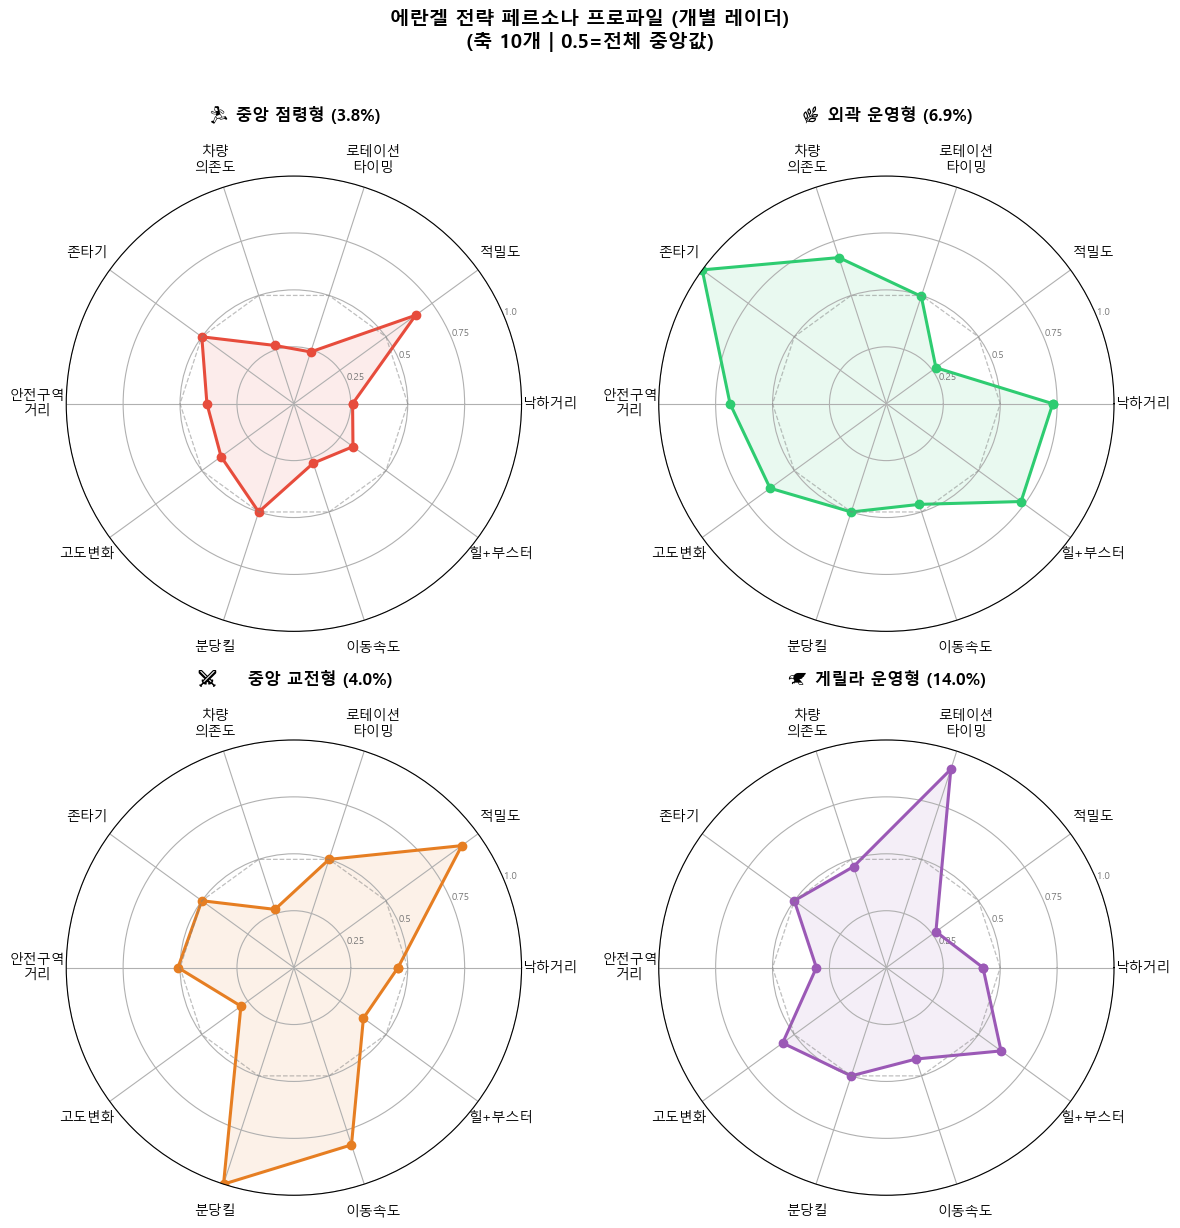

저장 완료: segment_radar_subplots.png


In [ ]:
import math

# --- persona별 레이더: subplot ---
n_persona = len(valid_order)
ncols = 2
nrows = math.ceil(n_persona / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(6*ncols, 6*nrows),
    subplot_kw={'polar': True}
)

# axes가 1개일 때/여러개일 때 통일 처리
axes = np.array(axes).reshape(-1)

for i, persona in enumerate(valid_order):
    ax = axes[i]
    color = PLOT_COLORS[i % len(PLOT_COLORS)]

    vals = df_norm.loc[persona, keep_cols].tolist()
    vals += [vals[0]]

    ax.plot(angles, vals, 'o-', linewidth=2.2, color=color)
    ax.fill(angles, vals, alpha=0.10, color=color)

    # 0.5 기준선
    ax.plot(angles, [0.5]*(N+1), '--', color='gray', linewidth=0.9, alpha=0.5)

    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7, color='#777')
    ax.set_ylim(0, 1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=10)
    ax.tick_params(axis='x', pad=10)

    # 타이틀에 승률 같이 표시
    wr_row = seg_results[seg_results['persona'] == persona]
    wr = wr_row['win_rate'].values[0] if not wr_row.empty else 0
    ax.set_title(f"{persona} ({wr:.1%})", fontsize=12, fontweight='bold', pad=18)

# 남는 subplot 축 제거
for j in range(n_persona, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    f'에란겔 전략 페르소나 프로파일 (개별 레이더)\n(축 {len(keep_cols)}개 | 0.5=전체 중앙값)',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'segment_radar_subplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: segment_radar_subplots.png')

In [ ]:
import math
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 0) Plotly 라벨 줄바꿈 처리: \n -> <br>, 특정 띄어쓰기 라벨 강제 줄바꿈
def wrap_label(s: str) -> str:
    s = s.replace("\n", "<br>")
    s = s.replace("차량 의존도", "차량<br>의존도")
    s = s.replace("로테이션 타이밍", "로테이션<br>타이밍")
    s = s.replace("안전구역 거리", "안전구역<br>거리")
    return s

radar_labels_plotly = [wrap_label(lbl) for lbl in radar_labels]

# 1) 기본 설정
personas = list(valid_order)
n = len(personas)

ncols = 2
nrows = math.ceil(n / ncols)

# subplot 위 제목
subplot_titles = list(personas) 

# 2) subplot 생성(행 간격)
fig = make_subplots(
    rows=nrows, cols=ncols,
    specs=[[{"type": "polar"} for _ in range(ncols)] for _ in range(nrows)],
    subplot_titles=subplot_titles,
    vertical_spacing=0.06,
    horizontal_spacing=0.15
)

theta_closed = radar_labels_plotly + [radar_labels_plotly[0]]

# 3) 페르소나별 레이더 trace 추가
for i, p in enumerate(personas):
    row = i // ncols + 1
    col = i % ncols + 1

    r = df_norm.loc[p, keep_cols].tolist()
    r_closed = r + [r[0]]

    color = PLOT_COLORS[i % len(PLOT_COLORS)]

    fig.add_trace(
        go.Scatterpolar(
            r=r_closed, theta=theta_closed,
            mode="lines+markers",
            line=dict(color=color, width=3),
            fill="toself",
            opacity=0.70,
            showlegend=False
        ),
        row=row, col=col
    )

    # 0.5 기준선
    fig.add_trace(
        go.Scatterpolar(
            r=[0.5] * len(theta_closed),
            theta=theta_closed,
            mode="lines",
            line=dict(color="gray", width=1, dash="dash"),
            opacity=0.55,
            showlegend=False
        ),
        row=row, col=col
    )

# 4) 전체 레이아웃(크기/타이틀)
fig.update_layout(
    height=650 * nrows,     # 겹치면 700*nrows로 올리기
    width=1200,             # 화면 좁으면 1400까지 올려도 됨
    margin=dict(l=70, r=70, t=90, b=60)
)

for ann in fig.layout.annotations:
    ann.font = dict(size=18, color="rgba(0,0,0,1.5)")  # 필요하면 size 조절
    ann.font.update(dict(family=None))  # 선택(기본 폰트 유지)
    # 굵게: HTML 태그로 처리하는 게 가장 확실
    ann.text = f"<b>{ann.text}</b>"

# 5) polar 축 공통 설정: radial tick 글씨 연회색
light_tick = "rgba(0,0,0,0.35)"  # 연한 회색(더 연하게=0.25, 더 진하게=0.45)

for k in range(1, n + 1):
    polar_name = "polar" if k == 1 else f"polar{k}"
    fig.layout[polar_name].radialaxis.update(
        range=[0, 1],
        tickvals=[0.25, 0.5, 0.75, 1.0],
        tickfont=dict(size=10, color=light_tick),
        gridcolor="rgba(0,0,0,0.12)"
    )
    fig.layout[polar_name].angularaxis.update(
        tickfont=dict(size=12),
        gridcolor="rgba(0,0,0,0.12)"
    )

fig.show()

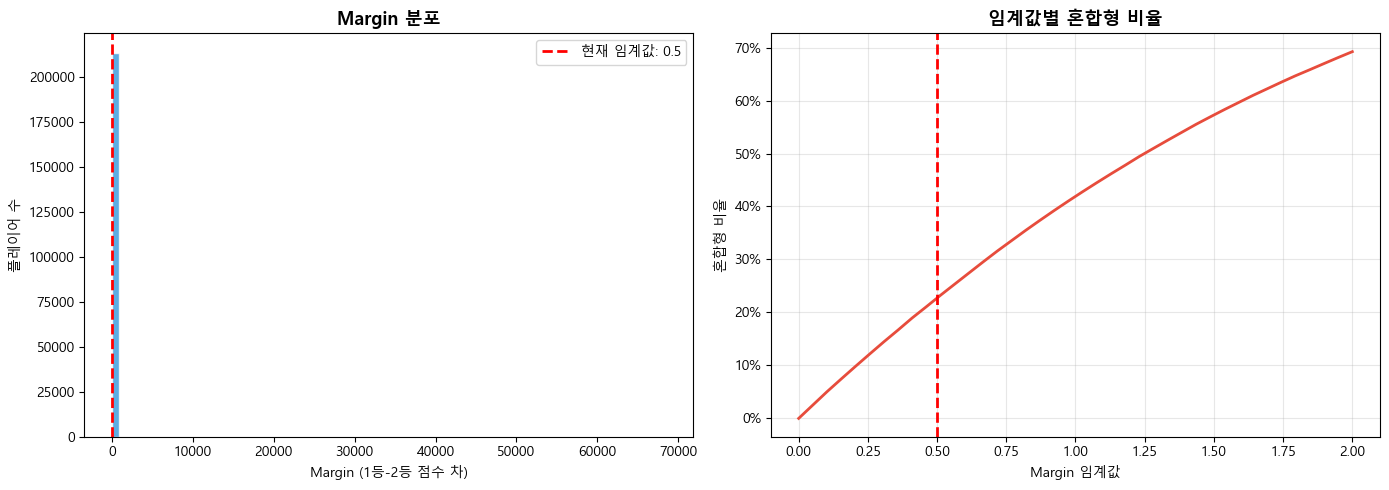

현재 임계값 0.5 기준:
  분류된 플레이어: 77.3%
  혼합형(uncertain): 22.7%

MARGIN_THRESHOLD를 조정하려면 Cell 6(STEP 5)의 값을 변경 후 Cell 6부터 재실행하세요.


In [ ]:
# STEP 10: Margin 분포 시각화 + 임계값 튜닝 가이드
#
# margin = 1등 페르소나 점수 - 2등 페르소나 점수
# 값이 클수록 해당 플레이어의 타입이 명확함
# 0.5 임계값이 적절한지 시각적으로 확인

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: margin 히스토그램
ax = axes[0]
ax.hist(df_clean['margin'], bins=80, color='#3498DB', edgecolor='white', alpha=0.8)
ax.axvline(MARGIN_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'현재 임계값: {MARGIN_THRESHOLD}')

ax.set_xlabel('Margin (1등-2등 점수 차)')
ax.set_ylabel('플레이어 수')
ax.set_title('Margin 분포', fontsize=13, fontweight='bold')
ax.legend()

# 오른쪽: 임계값별 uncertain 비율 + 4개 세그먼트 비율 변화
ax2 = axes[1]
thresholds = np.linspace(0, 2.0, 40)
unc_rates = [(df_clean['margin'] < t).mean() for t in thresholds]
ax2.plot(thresholds, unc_rates, color='#E74C3C', linewidth=2)
ax2.axvline(MARGIN_THRESHOLD, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Margin 임계값')
ax2.set_ylabel('혼합형 비율')
ax2.set_title('임계값별 혼합형 비율', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'margin_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'현재 임계값 {MARGIN_THRESHOLD} 기준:')
print(f'  분류된 플레이어: {(df_clean["margin"] >= MARGIN_THRESHOLD).mean():.1%}')
print(f'  혼합형(uncertain): {(df_clean["margin"] < MARGIN_THRESHOLD).mean():.1%}')
print()
print('MARGIN_THRESHOLD를 조정하려면 Cell 6(STEP 5)의 값을 변경 후 Cell 6부터 재실행하세요.')

In [ ]:
# ── 저장 전 중복 키 검증 ──
dup = df[['matchId','accountId']].duplicated()
if dup.any():
    raise RuntimeError(f" (matchId, accountId) 중복 {dup.sum()}건 — 저장 중단")
print(f" 중복 키 검증 통과")

# ── erangel_clustered.parquet 저장 ──
clustered_out = TRUTH_TABLES['erangel_clustered']
df.to_parquet(clustered_out, index=False)
print(f" 저장: {clustered_out}  ({df.shape[0]:,}행 × {df.shape[1]}열)")
print()
# STEP 11: 모델 저장
#
# 새 데이터에 동일한 세그먼트 분류를 적용하려면
# robust_z 함수와 각 피처의 median/MAD 값이 필요합니다.
# → fit_stats 딕셔너리로 저장

# 피처별 median / MAD 저장 (새 데이터 적용 시 재사용)
fit_stats = {}
for col in FEATURE_COLS_DISPLAY:
    med = df_clean[col].median()
    mad = (df_clean[col] - med).abs().median()
    mad = mad if mad != 0 else 1.0
    fit_stats[col] = {'median': med, 'mad': mad}

model_bundle = {
    'reducer':          reducer,        # UMAP (시각화 전용)
    'scaler':           scaler,
    'imputer':          imputer,
    'feature_cols':     FEATURE_COLS_DISPLAY,
    'fit_stats':        fit_stats,      # robust_z 재적용용
    'margin_threshold': MARGIN_THRESHOLD,
    'persona_labels':   PERSONA_LABELS,
    'profile':          profile,
    'seg_results':      seg_results,
}

with open(os.path.join(MODEL_DIR, 'erangel_model.pkl'), 'wb') as f:
    pickle.dump(model_bundle, f)

df_clean.to_parquet(os.path.join(OUTPUT_DIR, 'erangel_clustered.parquet'), index=False)

print('저장 완료!')
print(f'  모델: {MODEL_DIR}/erangel_model.pkl')
print(f'  데이터: {OUTPUT_DIR}/erangel_clustered.parquet')
print()
print('다음 단계: 03_apply_maps.ipynb')

 중복 키 검증 통과
 저장: C:\배그분석\analysis_output\erangel_clustered.parquet  (234,245행 × 28열)

저장 완료!
  모델: C:\배그분석\analysis_output\models/erangel_model.pkl
  데이터: C:\배그분석\analysis_output/erangel_clustered.parquet

다음 단계: 03_apply_maps.ipynb
